# 02 - Workload Analysis & Scenario Distributions

This notebook inspects the synthetic AI workload generator across the 6 benchmark scenarios:
- `balanced`
- `training_heavy`
- `short_job_heavy`
- `bursty`
- `gpu_fragmentation`
- `high_load`

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in python path
sys.path.insert(0, os.path.abspath('..'))

from workloads.scenarios import SCENARIOS, list_scenarios, create_scenario_workload

print("Available Scenarios:", list_scenarios())

Available Scenarios: ['balanced', 'training_heavy', 'short_job_heavy', 'bursty', 'gpu_fragmentation', 'high_load']


## 1. Scenario Summary Statistics

In [2]:
summary = []
for name in list_scenarios():
    jobs = create_scenario_workload(name, seed=42)
    runtimes = [j.actual_runtime for j in jobs]
    gpus = [j.gpu_count for j in jobs]
    vrams = [j.vram_per_gpu_gb for j in jobs]
    
    summary.append({
        "Scenario": name,
        "Job Count": len(jobs),
        "Avg Runtime (s)": round(np.mean(runtimes), 1),
        "Median Runtime (s)": round(np.median(runtimes), 1),
        "Avg GPU Count": round(np.mean(gpus), 2),
        "Avg VRAM (GB)": round(np.mean(vrams), 1),
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

         Scenario  Job Count  Avg Runtime (s)  Median Runtime (s)  Avg GPU Count  Avg VRAM (GB)
         balanced        288            127.8                86.4           2.65           37.8
   training_heavy        148            385.8               315.7           4.62           59.7
  short_job_heavy        692             27.7                24.2           1.42           20.0
           bursty        410             99.5                67.1           2.27           39.1
gpu_fragmentation        377            132.4                95.2           3.49           45.5
        high_load        983            136.7               104.5           2.56           40.1


## 2. Workload Distribution Visualizations

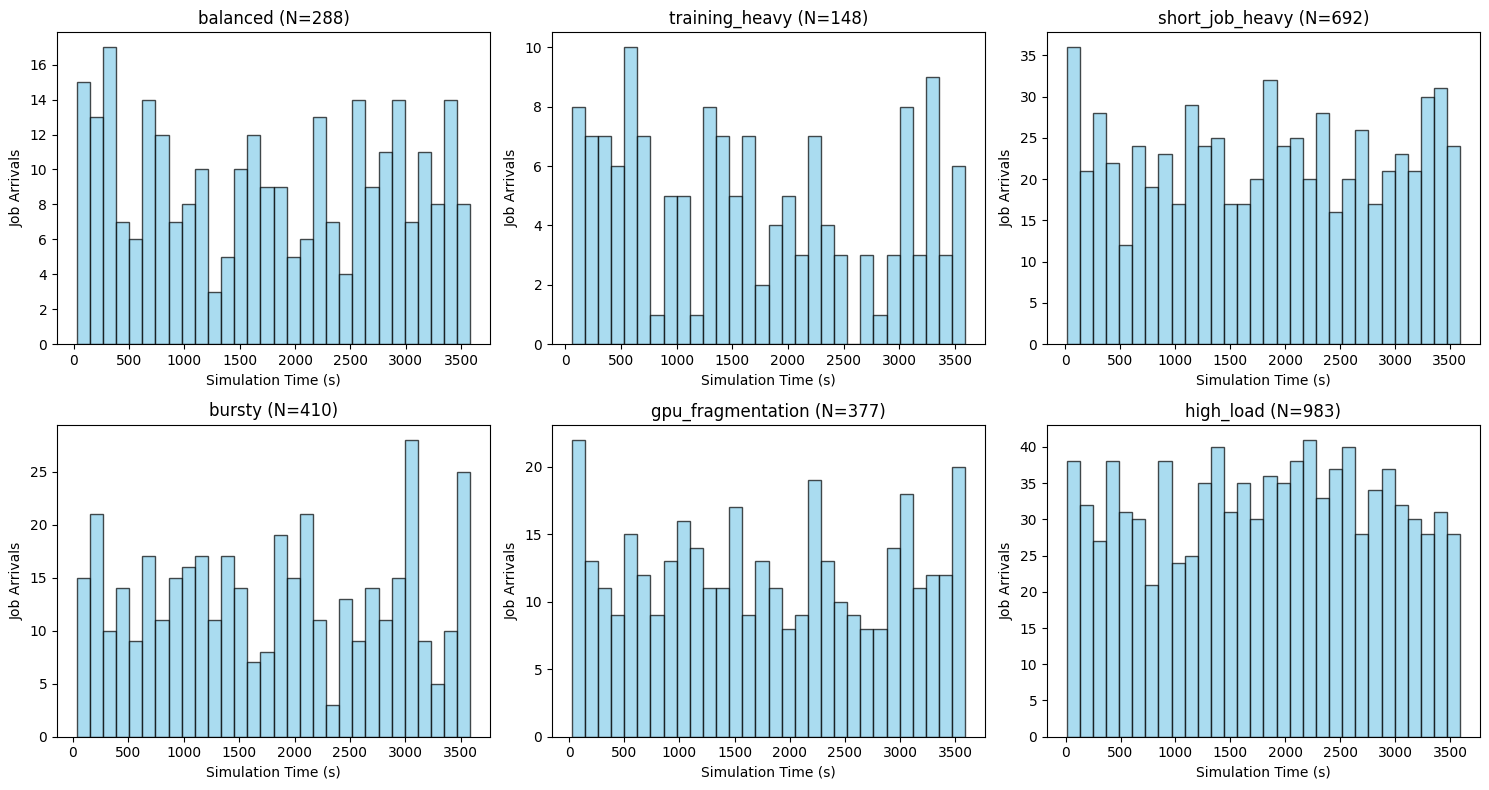

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, name in enumerate(list_scenarios()):
    jobs = create_scenario_workload(name, seed=42)
    arrivals = [j.arrival_time for j in jobs]
    axes[idx].hist(arrivals, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"{name} (N={len(jobs)})")
    axes[idx].set_xlabel("Simulation Time (s)")
    axes[idx].set_ylabel("Job Arrivals")

plt.tight_layout()
plt.show()